Finite-deadline DP with c = 0.03
t= 0: lower=0.170, upper=0.830
t= 1: lower=0.171, upper=0.829
t= 2: lower=0.174, upper=0.826
t= 3: lower=0.177, upper=0.823
t= 4: lower=0.181, upper=0.819
t= 5: lower=0.187, upper=0.813
t= 6: lower=0.197, upper=0.803
t= 7: lower=0.213, upper=0.787
t= 8: lower=0.242, upper=0.758
t= 9: lower=0.301, upper=0.699
t=10: lower=0.500, upper=0.500


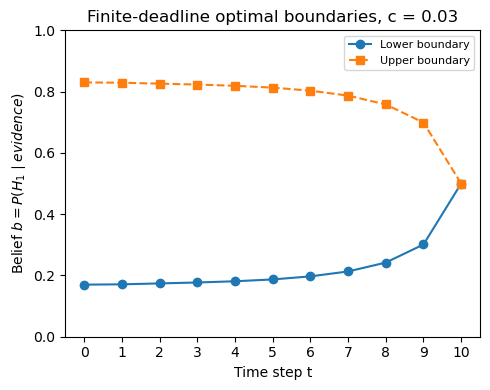

   trial  true_H  time_step  stim_idx  evidence_sum    belief  action
0      0       0          1        12           0.5  0.759747       2
1      0       0          2         3           0.0  0.500000       2
2      0       0          3        12           0.5  0.759747       2
3      0       0          4         4           0.1  0.557312       2
4      0       0          5         5          -0.2  0.386863       2
action
2    150890
1     25023
0     24977
Name: count, dtype: int64


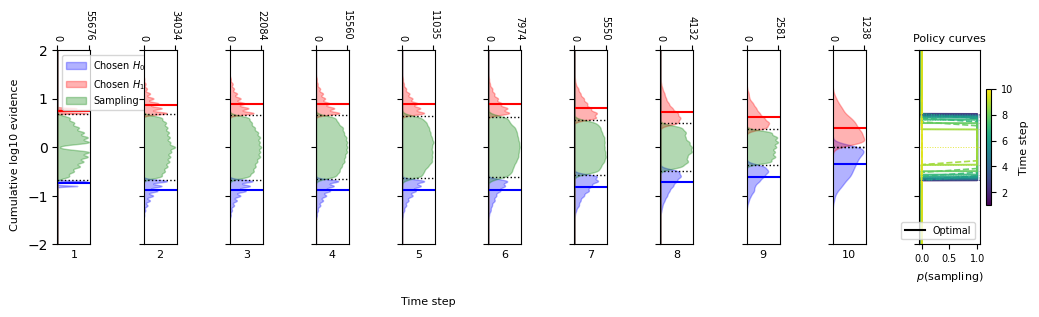

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

# ============================================================
# 1. Define task distribution and 16 stimulus evidence values
# ============================================================

mu = 2.2
sigma = 5.0
x = np.linspace(-15, 15, 500)

pdf_left = norm.pdf(x, -mu, sigma)    # H0 / Target A
pdf_right = norm.pdf(x, mu, sigma)    # H1 / Target B

log_ratio = np.log10(pdf_right / pdf_left)

target_log_ratios = np.array([
    -0.8, -0.7, -0.6, -0.5,
    -0.4, -0.3, -0.2, -0.1,
     0.1,  0.2,  0.3,  0.4,
     0.5,  0.6,  0.7,  0.8
])

x_targets = np.interp(target_log_ratios, log_ratio, x)

pB_raw = norm.pdf(x_targets, mu, sigma)
pA_raw = norm.pdf(x_targets, -mu, sigma)

pB = pB_raw / pB_raw.sum()
pA = pA_raw / pA_raw.sum()

# ============================================================
# 2. Finite-deadline dynamic programming
# Deadline: t = 11
# If t reaches 11, choices give no reward.
# Sampling still costs c.
# We compute decision boundaries for t = 0,...,10.
# ============================================================

c = 0.03

T_deadline = 11
max_decision_time = 10

N_b = 1001
b_grid = np.linspace(0, 1, N_b)

R_correct = 1.0
R_wrong = 0.0

# Stopping value before deadline
G = np.maximum(
    b_grid * R_correct + (1 - b_grid) * R_wrong,
    (1 - b_grid) * R_correct + b_grid * R_wrong
)

# Terminal value at deadline: no reward for any choice
G_deadline = np.zeros_like(b_grid)

# V[t, j] = value at time t and belief b_grid[j]
V = np.zeros((T_deadline + 1, N_b))
V[T_deadline, :] = G_deadline

lower_boundary = np.full(T_deadline + 1, np.nan)
upper_boundary = np.full(T_deadline + 1, np.nan)

policy_sample = np.zeros((T_deadline + 1, N_b), dtype=float)

# Backward induction: t = 10, 9, ..., 0
for t in range(T_deadline - 1, -1, -1):

    continue_value = np.zeros_like(b_grid)

    for j, b in enumerate(b_grid):

        expected_future_value = 0.0

        for i in range(len(pA)):

            q_i = b * pB[i] + (1 - b) * pA[i]

            if q_i > 0:
                b_next = (b * pB[i]) / q_i

                expected_future_value += q_i * np.interp(
                    b_next,
                    b_grid,
                    V[t + 1, :]
                )

        continue_value[j] = -c + expected_future_value

    # Before deadline, stopping has normal reward.
    # At t = 11, V is already fixed as zero.
    stop_value = G

    V[t, :] = np.maximum(stop_value, continue_value)

    continue_region = continue_value > stop_value
    policy_sample[t, :] = continue_region.astype(float)

    if np.any(continue_region):
        lower_boundary[t] = b_grid[continue_region][0]
        upper_boundary[t] = b_grid[continue_region][-1]
    else:
        lower_boundary[t] = 0.5
        upper_boundary[t] = 0.5

print(f"Finite-deadline DP with c = {c}")
for t in range(max_decision_time + 1):
    print(
        f"t={t:2d}: lower={lower_boundary[t]:.3f}, "
        f"upper={upper_boundary[t]:.3f}"
    )

# Convert belief boundaries to cumulative log10-odds boundaries
eps = 1e-12

lower_log_boundary = np.log10(
    np.clip(lower_boundary, eps, 1 - eps)
    / np.clip(1 - lower_boundary, eps, 1 - eps)
)

upper_log_boundary = np.log10(
    np.clip(upper_boundary, eps, 1 - eps)
    / np.clip(1 - upper_boundary, eps, 1 - eps)
)

log_odds_grid = np.log10(
    np.clip(b_grid, eps, 1 - eps)
    / np.clip(1 - b_grid, eps, 1 - eps)
)

# ============================================================
# 3. Plot finite-deadline boundaries in belief space
# ============================================================

t_plot = np.arange(max_decision_time + 1)

plt.figure(figsize=(5, 4))

plt.plot(
    t_plot,
    lower_boundary[:max_decision_time + 1],
    marker="o",
    label="Lower boundary"
)

plt.plot(
    t_plot,
    upper_boundary[:max_decision_time + 1],
    marker="s",
    linestyle="--",
    label="Upper boundary"
)

plt.xlabel("Time step t")
plt.ylabel(r"Belief $b=P(H_1 \mid evidence)$")
plt.title(f"Finite-deadline optimal boundaries, c = {c}")
plt.ylim(0, 1)
plt.xticks(t_plot)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ============================================================
# 4. Simulate 5 x 10^4 trials
# No noise, perfect integration
# Apply time-dependent optimal boundaries
# ============================================================

n_trials = 5 * 10**4
rng = np.random.default_rng(1)

sim_rows = []

for trial in range(n_trials):

    true_H = rng.integers(0, 2)  # 0 = H0/A, 1 = H1/B
    evidence_sum = 0.0

    for t in range(1, max_decision_time + 1):

        # Draw stimulus according to true hypothesis
        if true_H == 0:
            stim_idx = rng.choice(len(pA), p=pA)
        else:
            stim_idx = rng.choice(len(pB), p=pB)

        # Perfect noiseless integration of log10 likelihood ratio
        evidence_sum += target_log_ratios[stim_idx]

        # Convert cumulative log10 odds to belief
        b = 1.0 / (1.0 + 10.0 ** (-evidence_sum))

        # Use boundary for the current decision time
        if b <= lower_boundary[t]:
            action = 0   # choose A / H0
        elif b >= upper_boundary[t]:
            action = 1   # choose B / H1
        else:
            action = 2   # sample

        sim_rows.append({
            "trial": trial,
            "true_H": true_H,
            "time_step": t,
            "stim_idx": stim_idx,
            "evidence_sum": evidence_sum,
            "belief": b,
            "action": action
        })

        if action in [0, 1]:
            break

df_sim = pd.DataFrame(sim_rows)

print(df_sim.head())
print(df_sim["action"].value_counts())

# ============================================================
# 5. Distribution plot + attached policy curves
# ============================================================

colors_action = {
    0: "blue",
    1: "red",
    2: "green"
}

labels_action = {
    0: r'Chosen $H_0$', 
    1: r'Chosen $H_1$', 
    2: r'Sampling'
}

# Time-graded colors for policy curves
time_colors = plt.cm.viridis(
    np.linspace(0.1, 0.95, max_decision_time)
)

fig, axes = plt.subplots(
    1,
    max_decision_time + 1,
    figsize=(11, 3.2),
    sharey=True,
    gridspec_kw={
        "width_ratios": [1] * max_decision_time + [2.2]
    }
)

dist_axes = axes[:-1]
policy_ax = axes[-1]

y_min = -2
y_max = 2
y_grid = np.linspace(y_min, y_max, 1001)

# ============================================================
# 5A. Left panels: cumulative evidence distributions over time
# ============================================================

for t in range(1, max_decision_time + 1):

    ax = dist_axes[t - 1]
    timestep_data = df_sim[df_sim["time_step"] == t]

    max_density = 0.0

    for action in [0, 1, 2]:

        action_data = timestep_data[timestep_data["action"] == action]

        if action_data.empty:
            continue

        ev = action_data["evidence_sum"].to_numpy()

        if len(ev) < 3 or np.std(ev) == 0:
            continue

        kde = gaussian_kde(ev)
        density = kde(y_grid)

        # Scale by count to preserve frequency-like width
        density_scaled = density * len(ev)

        max_density = max(max_density, density_scaled.max())

        ax.fill_betweenx(
            y_grid,
            0,
            density_scaled,
            color=colors_action[action],
            alpha=0.3,
            label=labels_action[action] if t == 1 else None
        )

        if action in [0, 1]:
            mean_ev = np.mean(ev)
            ax.axhline(
                mean_ev,
                color=colors_action[action],
                linewidth=1.5
            )

    # Time-dependent optimal decision boundaries
    ax.axhline(
        lower_log_boundary[t],
        color="black",
        linestyle=":",
        linewidth=1
    )

    ax.axhline(
        upper_log_boundary[t],
        color="black",
        linestyle=":",
        linewidth=1
    )

    ax.set_ylim(y_min, y_max)

    if max_density > 0:
        ax.set_xlim(0, max_density * 1.05)
        ax.set_xticks([0, int(max_density)])
    else:
        ax.set_xlim(0, 1)
        ax.set_xticks([0, 1])

    ax.xaxis.set_ticks_position("top")
    ax.tick_params(
        axis="x",
        top=True,
        labeltop=True,
        labelbottom=False
    )

    ax.set_xticklabels(
        [str(int(x)) for x in ax.get_xticks()],
        rotation=270,
        fontsize=7
    )

    ax.set_xlabel(str(t), fontsize=8)

# ============================================================
# 5B. Right panel: policy curves
# p(sampling) as function of cumulative log10 odds
# Solid = optimal policy
# Dashed = empirical proportion from simulation
# ============================================================

n_bins = 50
ev_bins = np.linspace(y_min, y_max, n_bins + 1)
ev_centers = 0.5 * (ev_bins[:-1] + ev_bins[1:])

for idx, t in enumerate(range(1, max_decision_time + 1)):

    color_t = time_colors[idx]

    # ---------- Optimal policy curve ----------
    p_sample_optimal = (
        (log_odds_grid > lower_log_boundary[t])
        & (log_odds_grid < upper_log_boundary[t])
    ).astype(float)

    policy_ax.plot(
        p_sample_optimal,
        log_odds_grid,
        color=color_t,
        linewidth=1.4,
        alpha=0.9
    )

    # ---------- Empirical policy curve ----------
    timestep_data = df_sim[df_sim["time_step"] == t]

    ev = timestep_data["evidence_sum"].to_numpy()
    is_sampling = (timestep_data["action"] == 2).astype(float).to_numpy()

    p_sample_empirical = np.full_like(ev_centers, np.nan, dtype=float)

    for k in range(n_bins):
        mask = (ev >= ev_bins[k]) & (ev < ev_bins[k + 1])

        if mask.sum() >= 10:
            p_sample_empirical[k] = is_sampling[mask].mean()

    policy_ax.plot(
        p_sample_empirical,
        ev_centers,
        color=color_t,
        linestyle="--",
        linewidth=1.2,
        alpha=0.9
    )

# Boundary reference lines for each t
for t in range(1, max_decision_time + 1):
    policy_ax.axhline(
        lower_log_boundary[t],
        color=time_colors[t - 1],
        linestyle=":",
        linewidth=0.7,
        alpha=0.5
    )
    policy_ax.axhline(
        upper_log_boundary[t],
        color=time_colors[t - 1],
        linestyle=":",
        linewidth=0.7,
        alpha=0.5
    )

policy_ax.set_xlim(-0.05, 1.05)
policy_ax.set_xticks([0, 0.5, 1.0])
policy_ax.set_xlabel(r"$p(\mathrm{sampling})$", fontsize=8)
policy_ax.set_title("Policy curves", fontsize=8)
policy_ax.tick_params(axis="x", labelsize=7)

# Add small explanatory legend using dummy lines
policy_ax.plot([], [], color="black", linewidth=1.5, label="Optimal")
# policy_ax.plot([], [], color="black", linestyle="--", linewidth=1.5, label="Empirical")
policy_ax.legend(fontsize=7, loc="lower right")

# Add colorbar for time
sm = plt.cm.ScalarMappable(
    cmap="viridis",
    norm=plt.Normalize(vmin=1, vmax=max_decision_time)
)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=policy_ax,
    fraction=0.08,
    pad=0.08
)
cbar.set_label("Time step", fontsize=8)
cbar.ax.tick_params(labelsize=7)

# ============================================================
# Figure labels
# ============================================================

fig.text(
    0.44,
    0.03,
    "Time step",
    ha="center",
    fontsize=8
)

fig.text(
    0.06,
    0.5,
    "Cumulative log10 evidence",
    va="center",
    rotation="vertical",
    fontsize=8
)

for ax in dist_axes:
    ax.label_outer()

dist_axes[0].legend(loc="best", fontsize=7)

plt.tight_layout(rect=[0.05, 0.05, 1, 1])
plt.show()